In [41]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('/content/2019-10-13_ciannovostroyki.csv',
                 encoding='windows-1251',
                 sep=';',
                 engine='python',
                 on_bad_lines='skip',
                 skiprows=1)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37400 entries, 0 to 37399
Data columns (total 38 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Код                          37400 non-null  int64  
 1   Категория                    37400 non-null  object 
 2   Название                     37400 non-null  object 
 3   Тип продажи                  36796 non-null  object 
 4   Объект продажи               37400 non-null  object 
 5   Общая площадь                37400 non-null  object 
 6   Жилая площадь                37400 non-null  object 
 7   Площадь кухни                37400 non-null  object 
 8   Этаж                         37400 non-null  int64  
 9   Этажей в доме                37400 non-null  int64  
 10  Лифт пассажирский (кол-во)   35984 non-null  float64
 11  Лифт грузовой (кол-во)       35703 non-null  float64
 12  Год строительства            257 non-null    float64
 13  Балкон/лоджия   

In [4]:
columns = [
    'Стоимость',
    'Тип продажи',
    'Объект продажи',
    'Общая площадь',
    'Жилая площадь',
    'Площадь кухни',
    'Этаж',
    'Этажей в доме',
    'Лифт пассажирский (кол-во)',
    'Лифт грузовой (кол-во)',
    'Мусоропровод',
    'Парковка',
    'Количество комнат',
    'Тип дома',
    'Высота потолков',
    'Кол-во раздельных санузлов',
    'Вид из окон',
    'Расстояние до метро',
    'Округ',
    'Район'
]

In [5]:
t = df['Адрес'].map(
    lambda x:
      [
        s for s in x.split(',')[:3]
      ]
    )
df['Район'] = t.map(lambda x: x[-1])
df['Округ'] = t.map(lambda x: x[1])

In [6]:
df['Общая площадь'] = df['Общая площадь'].map(lambda x: float(x[2:-1]))
df['Жилая площадь'] = df['Жилая площадь'].map(lambda x: float(x[2:-1]) if len(x) > 3 else None)
df['Площадь кухни'] = df['Площадь кухни'].map(lambda x: float(x[2:-1]) if len(x) > 3 else None)

In [16]:
new_df = df[columns].drop_duplicates()
new_df

,Стоимость,Тип продажи,Объект продажи,Общая площадь,Жилая площадь,Площадь кухни,Этаж,Этажей в доме,Лифт пассажирский (кол-во),Лифт грузовой (кол-во),Мусоропровод,Парковка,Количество комнат,Тип дома,Высота потолков,Кол-во раздельных санузлов,Вид из окон,Расстояние до метро,Округ,Район
0,2850000,"Свободная продажа, Возможна ипотека",Новостройка,42.20,19.9,11.0,2,3,NaN,NaN,Нет,NaN,1.0,Кирпичный,NaN,1.0,Во двор,NaN,Богородский городской округ,Электроугли
1,7073030,", Возможна ипотека",Новостройка,70.03,41.8,13.7,2,17,1.0,1.0,Да,подземная,2.0,Монолитный,NaN,1.0,NaN,12 мин. на транспорте,НАО (Новомосковский),Щербинка
2,7799940,", Возможна ипотека",Новостройка,76.47,43.4,11.2,11,17,1.0,1.0,Да,подземная,3.0,Монолитный,NaN,1.0,Во двор,12 мин. на транспорте,НАО (Новомосковский),Щербинка
3,11700000,NaN,Новостройка,60.00,38.0,12.0,5,20,2.0,2.0,Нет,NaN,2.0,Монолитный,NaN,2.0,На улицу и двор,3 мин. на транспорте,СЗАО,район Хорошево-Мневники
4,6055000,", Возможна ипотека",Новостройка,65.20,NaN,NaN,2,5,0.0,1.0,Нет,подземная,2.0,Монолитный,NaN,0.0,На улицу и двор,NaN,Красногорск городской округ,д. Глухово
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37395,4312500,", Возможна ипотека",Новостройка,62.50,34.0,9.6,3,3,NaN,NaN,Нет,NaN,2.0,Кирпичный,NaN,1.0,На улицу и двор,NaN,Истра городской округ,д. Лобаново
37396,5102860,", Возможна ипотека",Новостройка,80.40,40.8,12.3,3,3,NaN,NaN,Нет,NaN,3.0,Кирпичный,NaN,1.0,На улицу и двор,23 мин. на транспорте,Истра городской округ,д. Лобаново
37397,5376000,", Возможна ипотека",Новостройка,84.00,45.0,12.5,3,3,NaN,NaN,Нет,NaN,3.0,Кирпичный,NaN,1.0,На улицу и двор,NaN,Истра городской округ,д. Исаково
37398,7000000,Свободная продажа,Новостройка,104.90,60.0,NaN,10,20,1.0,1.0,Да,NaN,3.0,NaN,3.0,2.0,На улицу и двор,NaN,Балашиха,улица Чистопольская


array([[<Axes: title={'center': 'Стоимость'}>,
        <Axes: title={'center': 'Общая площадь'}>,
        <Axes: title={'center': 'Жилая площадь'}>],
       [<Axes: title={'center': 'Площадь кухни'}>,
        <Axes: title={'center': 'Этаж'}>,
        <Axes: title={'center': 'Этажей в доме'}>],
       [<Axes: title={'center': 'Лифт пассажирский (кол-во)'}>,
        <Axes: title={'center': 'Лифт грузовой (кол-во)'}>,
        <Axes: title={'center': 'Количество комнат'}>],
       [<Axes: title={'center': 'Высота потолков'}>,
        <Axes: title={'center': 'Кол-во раздельных санузлов'}>, <Axes: >]],
      dtype=object)

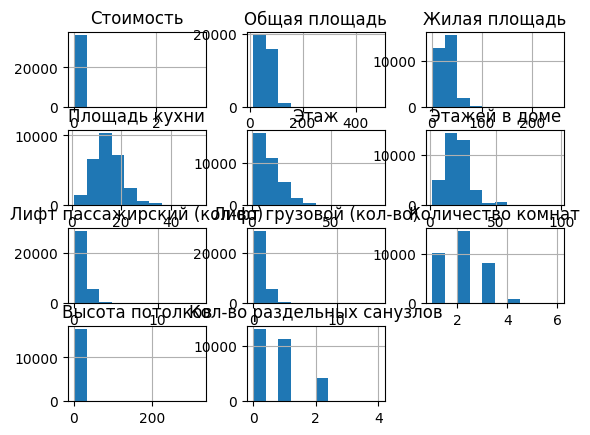

In [17]:
new_df.hist()

In [18]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(new_df, test_size=0.25)
valid, test = train_test_split(test, test_size=0.55)

In [21]:
from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder(
    min_frequency=26,
    handle_unknown='use_encoded_value',
    unknown_value=-1
).fit(train[train.dtypes[train.dtypes == object].index].fillna('-1'))

In [20]:
amount_cats = [len(i) for i in enc.categories_]
amount_inf_cats = [0 if i is None else len(i) for i in enc.infrequent_categories_]
amount_cats = [i - j for i, j in zip(amount_cats, amount_inf_cats)]
amount_cats

[7, 2, 2, 4, 5, 4, 50, 46, 153]

In [324]:
t = enc.transform(
    test[train.dtypes[train.dtypes == object].index].fillna('-1')
)
for i, cat in enumerate(amount_cats):
    t[t[:, i] == -1, i] = cat - 1

In [11]:
from sklearn.preprocessing import KBinsDiscretizer
kbdesc = KBinsDiscretizer(
    n_bins=128,
    encode='ordinal',
    strategy='kmeans'
).fit(
    train[
        train.dtypes[(train.dtypes == float) | (train.dtypes == int)].index
    ].fillna('-1')
)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (67) found smaller than n_clusters (128). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 4 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (62) found smaller than n_clusters (128). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 5 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: Co

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but QuantileTransformer was fitted with feature names
  warnings.warn(


(array([2.274e+03, 6.259e+03, 7.821e+03, 5.654e+03, 2.148e+03, 7.430e+02,
        9.840e+02, 6.270e+02, 4.090e+02, 2.340e+02, 1.130e+02, 3.700e+01,
        5.000e+00, 3.000e+00, 1.000e+00, 0.000e+00, 1.000e+00, 3.000e+00,
        1.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+0

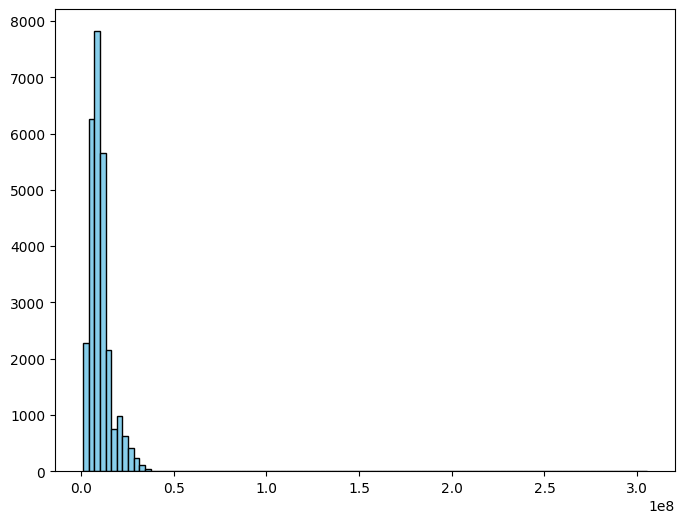

In [54]:
from sklearn.preprocessing import PowerTransformer, StandardScaler, QuantileTransformer
import matplotlib.pyplot as plt
pt = QuantileTransformer(output_distribution='normal')
data = pt.inverse_transform(pt.fit_transform(train[['Стоимость']]))
plt.figure(figsize=(8, 6))
plt.hist(data, bins=100, color='skyblue', edgecolor='black')

In [42]:
import dill
import os

In [263]:
class DataTransformer:
  def __init__(self,
               num_cfg,
               cat_cfg,
               target_cfg,
               ) -> None:
    self.num_path = num_cfg['path']
    self.cat_path = cat_cfg['path']
    self.target_path = target_cfg['path']

    self.num_processor = num_cfg['processor']
    self.cat_processor = cat_cfg['processor']
    self.target_processor = target_cfg['processor']

    self.num_cols = num_cfg['columns']
    self.cat_cols = cat_cfg['columns']
    self.target_cols = target_cfg['columns']

    if os.path.exists(num_cfg['path']):
      with open(num_cfg['path'], 'rb') as f:
        self.num_processor = dill.load(f)
    if os.path.exists(num_cfg['path']):
      with open(cat_cfg['path'], 'rb') as f:
        self.cat_processor = dill.load(f)
        self._set_cat_params()
    if os.path.exists(target_cfg['path']):
      with open(target_cfg['path'], 'rb') as f:
        self.target_processor = dill.load(f)

  def save(self):
    with open(self.num_path, 'wb') as f:
      dill.dump(self.num_processor, f)
    with open(self.cat_path, 'wb') as f:
      dill.dump(self.cat_processor, f)
    with open(self.target_path, 'wb') as f:
      dill.dump(self.target_processor, f)

  def _set_cat_params(self):
    cats = [
        len(i) for i in self.cat_processor.categories_
        ]
    inf_cats = [
        0 if i is None else len(i)
        for i in self.cat_processor.infrequent_categories_
        ]
    self.num_categories = [i - j for i, j in zip(cats, inf_cats)]

  def fit(self, data):
    # data = data.fillna('-1')
    # print(data['Тип продажи'].unique())
    self.num_processor.fit(data[self.num_cols].fillna(-1.0))
    print(1)
    self.cat_processor.fit(data[self.cat_cols])
                          #  .fillna('Пропущено значение'))
    print(2)
    self.target_processor.fit(data[self.target_cols])
    print(3)
    self._set_cat_params()

  def transform(self, data, is_target=False):
    # data = data.fillna('-1')
    if is_target:
      return self.target_processor.transform(data)
    else:
      num = self.num_processor.transform(data[self.num_cols].fillna(-1.0))
      cat = self.cat_processor.transform(data[self.cat_cols])
                                        #  .fillna('Пропущено значение'))
      for i, c in enumerate(self.num_categories):
        cat[cat[:, i] == -1, i] = c - 1
      return np.concat([num, cat], axis=1)

  def inverse_transform(self, data, is_target=False, numpy=True):
    if is_target:
      data = self.target_processor.inverse_transform(data)
      if numpy:
        return data
      else:
        return pd.DataFrame(data, columns=self.target_cols)
    else:
      i = len(self.num_cols)
      num = self.num_processor.inverse_transform(data[:, :i])
      num[num < 0] = np.nan
      cat = self.cat_processor.inverse_transform(data[:, i:])
      data = np.concat([num, cat], axis=1)
      if numpy:
        return data
      else:
        return pd.DataFrame(data, columns=self.num_cols + self.cat_cols)


In [264]:
from sklearn.compose import make_column_selector
# from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline

from sklearn.impute import SimpleImputer

num_cfg = {
  'processor': KBinsDiscretizer(n_bins=128, encode='ordinal', strategy='kmeans'),
  'columns': make_column_selector(dtype_include=np.number)(train),
  'path': 'num_processor.pkl'
}
cat_cfg = {
  'processor': OrdinalEncoder(min_frequency=26,
                              handle_unknown='use_encoded_value',
                              unknown_value=-1,
                              encoded_missing_value=-1),
  'columns': make_column_selector(dtype_include=object)(train),
  'path': 'cat_processor.pkl'
}
target_cfg = {
  'processor': PowerTransformer(),
  'columns': ['Стоимость'],
  'path': 'target_processor.pkl'
}
dt = DataTransformer(num_cfg, cat_cfg, target_cfg)

In [272]:
num_cfg, cat_cfg, target_cfg

({'processor': KBinsDiscretizer(encode='ordinal', n_bins=128, strategy='kmeans'),
  'columns': ['Стоимость',
   'Общая площадь',
   'Жилая площадь',
   'Площадь кухни',
   'Этаж',
   'Этажей в доме',
   'Лифт пассажирский (кол-во)',
   'Лифт грузовой (кол-во)',
   'Количество комнат',
   'Высота потолков',
   'Кол-во раздельных санузлов'],
  'path': 'num_processor.pkl'},
 {'processor': OrdinalEncoder(encoded_missing_value=-1, handle_unknown='use_encoded_value',
                 min_frequency=26, unknown_value=-1),
  'columns': ['Тип продажи',
   'Объект продажи',
   'Мусоропровод',
   'Парковка',
   'Тип дома',
   'Вид из окон',
   'Расстояние до метро',
   'Округ',
   'Район'],
  'path': 'cat_processor.pkl'},
 {'processor': PowerTransformer(),
  'columns': ['Стоимость'],
  'path': 'target_processor.pkl'})

In [266]:
# dt.cat_processor.fit(train[cat_cfg['columns']])
dt.fit(train)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (65) found smaller than n_clusters (128). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 4 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (65) found smaller than n_clusters (128). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 5 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: Co

1
2
3


In [267]:
dt.inverse_transform(dt.transform(valid), numpy=False)

,Стоимость,Общая площадь,Жилая площадь,Площадь кухни,Этаж,Этажей в доме,Лифт пассажирский (кол-во),Лифт грузовой (кол-во),Количество комнат,Высота потолков,Кол-во раздельных санузлов,Тип продажи,Объект продажи,Мусоропровод,Парковка,Тип дома,Вид из окон,Расстояние до метро,Округ,Район
0,8851578.08887,83.853648,56.881434,NaN,4.0,4.25,1.0,1.0,4.0,NaN,NaN,", Возможна ипотека",Новостройка,Нет,Наземная,Монолитный,NaN,17 мин. на транспорте,Красногорск городской округ,infrequent_sklearn
1,8658131.789098,59.705075,22.879503,21.66576,13.0,33.0,2.25,2.0,2.0,0.25,2.0,"Долевое участие (214-ФЗ), Возможна ипотека",Новостройка,Нет,Неизвестно,Монолитный,Во двор,2 мин. на транспорте,ЮВАО,район Рязанский
2,2690768.532663,24.919608,16.006623,NaN,17.0,17.0,1.0,1.0,NaN,NaN,0.0,"Долевое участие (214-ФЗ), Возможна ипотека",Новостройка,Нет,Неизвестно,Монолитный,NaN,13 мин. на транспорте,Ленинский городской округ,д. Мисайлово
3,7917213.323693,83.853648,43.110661,14.276134,3.0,14.0,1.0,1.0,3.25,2.65,2.0,"Долевое участие (214-ФЗ), Возможна ипотека",Новостройка,Нет,Неизвестно,Панельный,На улицу и двор,7 мин. пешком,Люберцы,микрорайон Городок Б
4,21931062.13226,72.649239,43.777654,10.313348,36.0,36.0,1.0,1.0,3.25,3.0975,1.0,"Долевое участие (214-ФЗ), Возможна ипотека",Новостройка,Нет,подземная,Монолитный,На улицу и двор,3 мин. на транспорте,СЗАО,район Хорошево-Мневники
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4093,5716269.47391,39.52324,14.899526,9.38904,2.25,9.0,1.0,1.0,0.75,2.8,0.0,"Долевое участие (214-ФЗ), Возможна ипотека",Новостройка,Нет,Наземная,Монолитный,NaN,NaN,НАО (Новомосковский),Десеновское поселение
4094,14153830.686355,65.119252,35.122515,11.619526,15.0,22.0,1.0,0.25,2.0,NaN,1.0,"Долевое участие (214-ФЗ), Возможна ипотека",Новостройка,Нет,подземная,Монолитный,Во двор,7 мин. пешком,СЗАО,район Покровское-Стрешнево
4095,3418251.974782,30.541577,13.000925,7.343813,12.0,17.0,1.0,1.0,0.75,2.8,0.0,"Долевое участие (214-ФЗ), Возможна ипотека",Новостройка,Нет,Неизвестно,Монолитный,На улицу,3 мин. на транспорте,Люберцы,микрорайон Люберцы 2015 2018
4096,4393572.568359,34.271895,12.240743,NaN,10.0,14.0,2.25,1.0,NaN,NaN,NaN,", Возможна ипотека",Новостройка,Нет,NaN,Монолитный,На улицу,40 мин. на транспорте,Солнечногорск городской округ,infrequent_sklearn


In [268]:
dt.save()

In [269]:
dt = DataTransformer(num_cfg, cat_cfg, target_cfg)

In [271]:
dt.inverse_transform(dt.transform(valid), numpy=False)
# dt.transform(valid)

,Стоимость,Общая площадь,Жилая площадь,Площадь кухни,Этаж,Этажей в доме,Лифт пассажирский (кол-во),Лифт грузовой (кол-во),Количество комнат,Высота потолков,Кол-во раздельных санузлов,Тип продажи,Объект продажи,Мусоропровод,Парковка,Тип дома,Вид из окон,Расстояние до метро,Округ,Район
0,8851578.08887,83.853648,56.881434,NaN,4.0,4.25,1.0,1.0,4.0,NaN,NaN,", Возможна ипотека",Новостройка,Нет,Наземная,Монолитный,NaN,17 мин. на транспорте,Красногорск городской округ,infrequent_sklearn
1,8658131.789098,59.705075,22.879503,21.66576,13.0,33.0,2.25,2.0,2.0,0.25,2.0,"Долевое участие (214-ФЗ), Возможна ипотека",Новостройка,Нет,Неизвестно,Монолитный,Во двор,2 мин. на транспорте,ЮВАО,район Рязанский
2,2690768.532663,24.919608,16.006623,NaN,17.0,17.0,1.0,1.0,NaN,NaN,0.0,"Долевое участие (214-ФЗ), Возможна ипотека",Новостройка,Нет,Неизвестно,Монолитный,NaN,13 мин. на транспорте,Ленинский городской округ,д. Мисайлово
3,7917213.323693,83.853648,43.110661,14.276134,3.0,14.0,1.0,1.0,3.25,2.65,2.0,"Долевое участие (214-ФЗ), Возможна ипотека",Новостройка,Нет,Неизвестно,Панельный,На улицу и двор,7 мин. пешком,Люберцы,микрорайон Городок Б
4,21931062.13226,72.649239,43.777654,10.313348,36.0,36.0,1.0,1.0,3.25,3.0975,1.0,"Долевое участие (214-ФЗ), Возможна ипотека",Новостройка,Нет,подземная,Монолитный,На улицу и двор,3 мин. на транспорте,СЗАО,район Хорошево-Мневники
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4093,5716269.47391,39.52324,14.899526,9.38904,2.25,9.0,1.0,1.0,0.75,2.8,0.0,"Долевое участие (214-ФЗ), Возможна ипотека",Новостройка,Нет,Наземная,Монолитный,NaN,NaN,НАО (Новомосковский),Десеновское поселение
4094,14153830.686355,65.119252,35.122515,11.619526,15.0,22.0,1.0,0.25,2.0,NaN,1.0,"Долевое участие (214-ФЗ), Возможна ипотека",Новостройка,Нет,подземная,Монолитный,Во двор,7 мин. пешком,СЗАО,район Покровское-Стрешнево
4095,3418251.974782,30.541577,13.000925,7.343813,12.0,17.0,1.0,1.0,0.75,2.8,0.0,"Долевое участие (214-ФЗ), Возможна ипотека",Новостройка,Нет,Неизвестно,Монолитный,На улицу,3 мин. на транспорте,Люберцы,микрорайон Люберцы 2015 2018
4096,4393572.568359,34.271895,12.240743,NaN,10.0,14.0,2.25,1.0,NaN,NaN,NaN,", Возможна ипотека",Новостройка,Нет,NaN,Монолитный,На улицу,40 мин. на транспорте,Солнечногорск городской округ,infrequent_sklearn


In [273]:
os.path.dirname(os.path.dirname(os.path.abspath(__file__)))

NameError: name '__file__' is not defined

In [275]:
# train.to_csv('train_data.csv')
valid.to_csv('valid_data.csv')
test.to_csv('text_data.csv')